# imports & setup

In [1]:
from pathlib import Path
from typing import Any, Literal
import json

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors

# scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
import sklearn.base
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import parse_cls, DistanceTensorResult
from attention_motifs.features.plotting import plot_embedding
from attention_motifs.features.head_analysis import filter_umap_warns
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

# load dists

In [4]:
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "head_dists.zanj"
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)

[ <ipykernel>:4 ] HEAD_DISTS.distances: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64
[ <ipykernel>:5 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


array([[ 0.        ,  8.69202432,  9.54040428, ..., 12.25940865,
        12.16375817, 12.23178058],
       [ 8.69202432,  0.        ,  9.8659314 , ...,  9.98180279,
         9.99545272,  9.95879912],
       [ 9.54040428,  9.8659314 ,  0.        , ...,  8.9271944 ,
         8.64037894,  8.91942945],
       ...,
       [12.25940865,  9.98180279,  8.9271944 , ...,  0.        ,
         1.75838832,  1.64093945],
       [12.16375817,  9.99545272,  8.64037894, ...,  1.75838832,
         0.        ,  1.69310037],
       [12.23178058,  9.95879912,  8.91942945, ...,  1.64093945,
         1.69310037,  0.        ]])

In [5]:
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

# head projection & clustering

In [12]:
def create_head_embedding_df(
    head_dists: DistanceTensorResult,
    attnpedia: AttentionPedia|None = None,
    embedding_method: Literal["isomap", "umap", "tsne", "pca"] = "isomap",
    n_components: int = 3,
    n_neighbors: int = 15,
    reducer_kwargs: dict[str, Any]|None = None,
) -> pl.DataFrame:
    """
    Create a polars DataFrame from head distance data, with embeddings and type information.
    
    # Parameters:
     - `head_dists : DistanceTensorResult`
        The head distances object containing cls_values and distances
     - `attnpedia : Optional[AttentionPedia]`
        AttentionPedia object for head type lookups, if None a new one will be created
     - `embedding_method : Literal["isomap", "umap", "tsne", "pca"]`
        Method to use for dimensionality reduction
     - `n_components : int`
        Number of dimensions for the embedding (default: 3)
     - `n_neighbors : int`
        Number of neighbors to consider for manifold methods (default: 15)
     - `random_state : int`
        Random seed for reproducibility (default: 42)
    
    # Returns:
     - `pl.DataFrame`
        A dataframe with one row per head, containing:
        - cls string
        - model, layer, head extracted from cls
        - embedding dimensions (embed.0, embed.1, etc.)
        - head types (primary_type and all_types)
    """
    # kwargs
    reducer_kwargs_: dict[str, Any] = reducer_kwargs or {}
    # Create AttentionPedia if not provided
    if attnpedia is None:
        attnpedia = AttentionPedia()
    
    # Get distance matrix
    distance_matrix: Float[np.ndarray, "n_heads n_heads"] = head_dists.mean_dists
    
    # Create embedding based on specified method
    reducer: sklearn.base.BaseEstimator
    match embedding_method:
        case "isomap":
            reducer = Isomap(
                n_neighbors=n_neighbors,
                n_components=n_components,
                metric="precomputed",
                **reducer_kwargs_,
            )
        case "umap":
            filter_umap_warns()
            reducer = umap.UMAP(
                n_neighbors=n_neighbors,
                n_components=n_components,
                metric="precomputed",
                **reducer_kwargs_,
            )
        case "tsne":
            reducer = TSNE(
                n_components=n_components,
                metric="precomputed",
                **reducer_kwargs_,
            )
        case "pca":
            # For PCA, we need to convert distances to similarity
            # This is a simple approach - might need more sophisticated methods
            similarity_matrix = 1 / (1 + distance_matrix)
            np.fill_diagonal(similarity_matrix, 1.0)
            reducer = PCA(n_components=n_components, **reducer_kwargs_,)
        case _:
            raise ValueError(f"Unknown embedding method: {embedding_method}")
    
    # Perform embedding
    if embedding_method == "pca":
        embedding: np.ndarray = reducer.fit_transform(similarity_matrix)
    else:
        embedding: np.ndarray = reducer.fit_transform(distance_matrix)
    
    # Parse cls values
    parsed_cls: list[tuple[str, int, int]] = [parse_cls(cls_) for cls_ in head_dists.cls_values]
    models: list[str] = [model for model, _, _ in parsed_cls]
    layers: list[int] = [layer for _, layer, _ in parsed_cls]
    heads: list[int] = [head for _, _, head in parsed_cls]
    
    # Get head types
    head_to_type: dict[str, str] = attnpedia.head_to_type()
    head_to_types: dict[str, list[str]] = attnpedia.head_to_types()
    
    primary_types: list[str] = [head_to_type.get(cls, "unknown") for cls in head_dists.cls_values]
    all_types: list[str] = [
        ", ".join(head_to_types.get(cls, ["unknown"])) 
        for cls in head_dists.cls_values
    ]
    
    # Create basic dataframe
    df: pl.DataFrame = pl.DataFrame({
        "cls": head_dists.cls_values,
        "model": models,
        "layer": layers,
        "head": heads,
        "primary_type": primary_types,
        "all_types": all_types,
    })
    
    # Add embedding columns
    for i in range(n_components):
        df = df.with_columns(
            pl.Series(f"embed.{i}", embedding[:, i])
        )
    
    # HACK: add metadata
    df._embed_meta = dict(
        embedding_method=embedding_method,
        n_components=n_components,
        n_neighbors=n_neighbors,
        reducer_kwargs=reducer_kwargs,
    )
    
    return df

HEAD_EMBED_DF: pl.DataFrame = create_head_embedding_df(
    head_dists=HEAD_DISTS,
    attnpedia=ATTENTIONPEDIA,
    embedding_method="isomap",
    n_components=3,
    n_neighbors=15,
)

/tmp/ipykernel_85491/3081397591.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('tab20', len(categories))


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': "Head Embeddings via isomap\nn_components=3, n_neighbors=15, reducer_kwargs=None\ncolored by 'primary_type' (13 categories)"}, xlabel='Dimension 0', ylabel='Dimension 1'>)

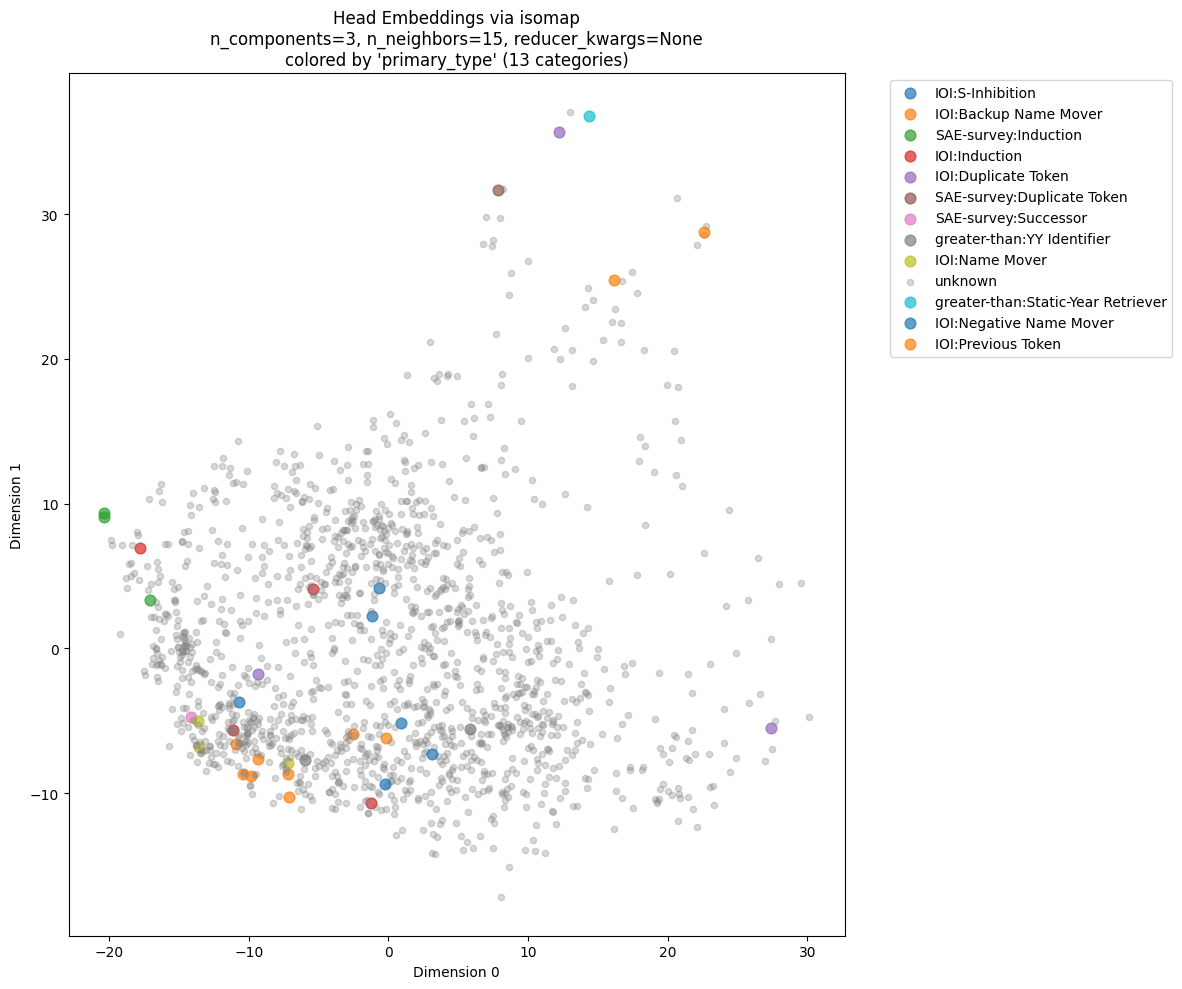

In [15]:

def plot_head_embeddings(
        df: pl.DataFrame,
        color_by: str = "primary_type",
        dims: tuple[int, int] = (0, 1),
        alphas: tuple[float, float] = (0.7, 0.3),
        sizes: tuple[int, int] = (60, 20),
        unknown_color: str = "gray",
    ):
    """Plot head embeddings colored by the specified column"""
    fig: plt.Figure; ax: plt.Axes
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Get unique values for color assignment
    categories: list = df[color_by].unique().to_list()
    cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('tab20', len(categories))
    color_map: dict = {cat: cmap(i) for i, cat in enumerate(categories)}
    
    # Extract embedding dimensions
    x_col: str = f"embed.{dims[0]}"
    y_col: str = f"embed.{dims[1]}"
    
    # Create scatter plot
    for cat in categories:
        cat_df: pl.DataFrame = df.filter(pl.col(color_by) == cat)
        scatter_kwargs: dict = dict(
            alpha=alphas[0] if cat != "unknown" else alphas[1],
            s=sizes[0] if cat != "unknown" else sizes[1],
        )
        if cat == "unknown":
            scatter_kwargs["color"] = unknown_color
        ax.scatter(
            cat_df[x_col], 
            cat_df[y_col],
            label=cat,
            **scatter_kwargs,
        )
    
    ax.set_xlabel(f"Dimension {dims[0]}")
    ax.set_ylabel(f"Dimension {dims[1]}")
    title: str = (
        f"Head Embeddings via {df._embed_meta['embedding_method']}\n"
        f"n_components={df._embed_meta['n_components']}, n_neighbors={df._embed_meta['n_neighbors']}, reducer_kwargs={df._embed_meta['reducer_kwargs']}\n"
        f"colored by '{color_by}' ({len(categories)} categories)"
    )
    ax.set_title(title)
    
    # Add legend (potentially outside plot for many categories)
    if len(categories) > 10:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend()
    
    plt.tight_layout()
    return fig, ax

plot_head_embeddings(
    HEAD_EMBED_DF,
    color_by="primary_type",
    dims=(0, 1)
)

In [ ]:



def reduce_and_plot_heads(
	head_dists: DistanceTensorResult,
	n_neighbors_list: list[int] | None = None,
	method: str = "isomap",
	n_components: int = 2,
	attnpedia_map: dict[str, str] = AttentionPedia().head_to_type(),
) -> None:
	"""
	Compute a low-dimensional embedding for each ``n_neighbors`` value and plot it.

	Parameters
	----------
	head_dists
	    A ``DistanceTensorResult`` whose ``mean_dists`` field is a pre-computed
	    pair-wise distance matrix (shape: n_heads x n_heads).
	n_neighbors_list
	    Values to sweep for the neighborhood size; defaults to
	    ``[2, 4, 8, 16, 32, 64]``.
	method
	    Either ``"isomap"`` (default) or ``"umap"``.  UMAP is available as a
	    fallback if you ever want to compare results.
	n_components
	    Target dimensionality (default: ``2``).
	"""
	if n_neighbors_list is None:
		n_neighbors_list = [2, 4, 8, 16, 32, 64]

	# One panel per neighborhood size
	fig, axs = plt.subplots(
		1,
		len(n_neighbors_list),
		figsize=(10 * len(n_neighbors_list), 10),
		squeeze=False,
	)
	axs = axs[0]

	# Labels for coloring points
	labels = pl.Series([attnpedia_map.get(h, "unknown") for h in head_dists.cls_values])

	for ax, n_neighbors in zip(axs, n_neighbors_list):
		if method.lower() == "isomap":
			reducer = Isomap(
				n_neighbors=n_neighbors,
				n_components=n_components,
				metric="precomputed",
			)
		elif method.lower() == "umap":
			import umap  # local import to avoid hard dependency

			reducer = umap.UMAP(
				n_neighbors=n_neighbors,
				n_components=n_components,
				metric="precomputed",
				init="spectral",
				min_dist=0.1,
				random_state=0,
			)
		else:
			raise ValueError(f"Unknown method: {method!r}")

		embedding: np.ndarray = reducer.fit_transform(head_dists.mean_dists)

		plot_embedding(
			embedding,
			labels=labels,
			dims=(0, 1),
			alpha={"unknown": 0.3, None: 0.9},
			marker_size={"unknown": 15, None: 60},
			title=f"{method.upper()} embedding (n_neighbors={n_neighbors})",
			ax=ax,
		)

	plt.tight_layout()
	plt.show()


head_dists_gpt2small: DistanceTensorResult = HEAD_DISTS.match_cls("gpt2-small")
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(head_dists_gpt2small.distances)


reduce_and_plot_heads(
	head_dists=head_dists_gpt2small,
	n_neighbors_list=[2, 8, 32],
	method="isomap",
	n_components=2,
	attnpedia_map=ATTENTIONPEDIA.head_to_type(),
)

In [ ]:
ATTENTIONPEDIA.type_to_heads().keys()

# heirarchical clustering

In [ ]:
def plot_hclust(
	dist_mat: Float[np.ndarray, "h h"],
	labels: list[str],
	*,
	method: str = "average",
	leaf_font_size: int = 6,
	truncate: int | None = None,
	show_heatmap: bool = True,
) -> tuple[np.ndarray, list[str], dict[str, Any]]:
	"""Hierarchical clustering dendrogram (plus optional heat-map).

	# Parameters
	 - `dist_mat : Float[np.ndarray, "h h"]`
	    Square distance matrix (symmetric, zero diagonal).
	 - `labels : list[str]`
	    Observation names, length `h`.
	 - `method : str`
	    Linkage criterion for `scipy.cluster.hierarchy.linkage`.
	 - `leaf_font_size : int`
	    Tick-label font size.
	 - `truncate : int | None`
	    If given, plot the dendrogram in *last-p* mode with `p = truncate`.
	 - `show_heatmap : bool`
	    Draw reordered distance matrix.
	 - `figsize : tuple[int, int] | None`
	    Figure size; if `None`, pick a reasonable default.

	# Returns
	 - `np.ndarray`
	    Linkage matrix `Z` (`h - 1`, 4).
	 - `dict[str, Any]`
	    Dot-list representation of the tree **as actually plotted**
	    (clusters are collapsed when `truncate` is used).
	"""
	h: int = dist_mat.shape[0]

	# ---------- sanity checks
	if dist_mat.shape != (h, h):
		raise ValueError("dist_mat must be square")
	if len(labels) != h:
		raise ValueError("labels length must match dist_mat")
	if not np.allclose(dist_mat, dist_mat.T):
		raise ValueError("dist_mat must be symmetric")
	if not np.all(np.diag(dist_mat) == 0):
		raise ValueError("dist_mat diagonal must be zero")

	# ---------- linkage
	condensed: Float[np.ndarray, "h*(h-1)//2"] = squareform(dist_mat, checks=False)
	Z: np.ndarray = linkage(condensed, method=method)

	# ---------- dendrogram
	_, ax_dend = plt.subplots(figsize=(8, 4))
	dend_kw: dict[str, object] = {
		"labels": labels,
		"leaf_rotation": 90,
		"leaf_font_size": leaf_font_size,
		"distance_sort": "ascending",
	}
	if truncate is not None:
		dend_kw.update({"truncate_mode": "lastp", "p": truncate})

	dendro: dict[str, Any] = dendrogram(Z, **dend_kw, ax=ax_dend)
	ax_dend.set_ylabel("Distance")
	ax_dend.set_title(f"Hierarchical clustering ({method} linkage)")
	# ax_dend.set_ylim(7, 27)
	plt.tight_layout()
	plt.show()

	# ---------- helpers
	def _members(node_id: int, *, n: int = h) -> list[int]:
		"""Return all original leaf indices contained in `node_id`."""
		if node_id < n:
			return [node_id]
		left: int = int(Z[node_id - n, 0])
		right: int = int(Z[node_id - n, 1])
		return _members(left, n=n) + _members(right, n=n)

	visible_ids: set[int] = set(dendro["leaves"])

	# ---------- heat-map
	order: list[int]
	if truncate is None:
		order = list(dendro["leaves"])
	else:
		order = [idx for node in dendro["leaves"] for idx in _members(node)]
	labels_ordered: list[str] = [labels[i] for i in order]
	if show_heatmap:
		reordered: Float[np.ndarray, "h h"] = dist_mat[np.ix_(order, order)]

		_, ax_hm = plt.subplots(figsize=(30, 30))
		im = ax_hm.imshow(reordered, aspect="auto")
		ax_hm.set_xticks(np.arange(h))
		ax_hm.set_yticks(np.arange(h))
		ax_hm.set_xticklabels(labels_ordered, rotation=90, fontsize=leaf_font_size)
		ax_hm.set_yticklabels(labels_ordered, fontsize=leaf_font_size)
		ax_hm.set_xlabel("Classes")
		ax_hm.set_ylabel("Classes")
		ax_hm.set_title("Distance matrix (reordered)")
		ax_hm.set_aspect("equal")
		plt.colorbar(im, ax=ax_hm)
		plt.tight_layout()
		plt.show()

	# ---------- dot-list
	def _dot_tree(node_id: int, path: str = "") -> dict[str, Any]:
		key: str = path.rstrip(".") or "root"
		if node_id in visible_ids:  # displayed leaf/cluster
			mem: list[int] = _members(node_id)
			return {key: labels[mem[0]] if len(mem) == 1 else [labels[m] for m in mem]}
		left, right = (int(x) for x in Z[node_id - h, :2])
		dot: dict[str, Any] = {}
		dot.update(_dot_tree(left, f"{path}0."))
		dot.update(_dot_tree(right, f"{path}1."))
		return dot

	tree_dict: dict[str, Any] = _dot_tree(2 * h - 2)

	return Z, labels_ordered, tree_dict


linkages, labels_sorted, tree = plot_hclust(
	HEAD_DISTS.mean_dists,
	labels=HEAD_DISTS.cls_values,
	truncate=100,
	# show_heatmap=False,
)

dbg_tensor(linkages)
leaf_lens: dict[str, int] = {k: len(v) for k, v in tree.items()}
plt.hist(
	leaf_lens.values(),
	bins=50,
)
plt.show()
print(
	json.dumps(
		leaf_lens,
		indent=2,
	)
)

In [ ]:
import itertools

tree_known_types: dict[str, set[str]] = {
	k: set(
		itertools.chain.from_iterable(
			[ATTENTIONPEDIA.head_to_types().get(h, ["unknown"]) for h in v]
		)
	)
	for k, v in tree.items()
}
tree_known_types

In [ ]:
known_types_to_leaf: dict[str, set[str]] = {
	t: set([head for head, types in tree_known_types.items() if t in types])
	for t in [*ATTENTIONPEDIA.type_to_heads().keys(), "unknown"]
}
known_types_to_leaf